- **학습 목표**: 이진 분류 데이터의 클래스 불균형과 특성 스케일 차이를 먼저 파악한다.
- **핵심 개념**: 클래스 분포가 한쪽으로 치우쳐 있으면 "정확도(accuracy)"만으로는 모델을 평가할 수 없습니다. 오늘 ROC/AUC를 배우는 이유가 여기 있습니다.

In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
import pandas as pd
from collections import Counter

In [2]:
def inspect_breast_cancer():
  """
  요구사항:
  - load_breast_cancer()로 X, y, target_names를 가져온다.
  - X.shape, 클래스 이름, 클래스별 샘플 수를 출력한다.
  - pandas DataFrame으로 만들어 앞 5개 특성의 describe()를 출력한다.
  - 특성들 사이 스케일(평균, 표준편차) 차이가 얼마나 큰지 확인한다.
  """
  data = load_breast_cancer()
  X, y, target_names = data.data, data.target, data.target_names
  print(f"X.shape : {X.shape}")
  print(f"target_names : {target_names}")
  print(f"{target_names[0]} : {np.unique(y, return_counts=True)[1][0]}")
  print(f"{target_names[1]} : {np.unique(y, return_counts=True)[1][1]}")
  data_frame = pd.DataFrame(X)
  print(data_frame.describe().head(5))
  print(f"평균 : {np.mean(X, axis=0)}")
  print(f"표준편차 : {np.std(X, axis=0)}")
inspect_breast_cancer()

X.shape : (569, 30)
target_names : ['malignant' 'benign']
malignant : 212
benign : 357
               0           1           2           3           4           5   \
count  569.000000  569.000000  569.000000  569.000000  569.000000  569.000000   
mean    14.127292   19.289649   91.969033  654.889104    0.096360    0.104341   
std      3.524049    4.301036   24.298981  351.914129    0.014064    0.052813   
min      6.981000    9.710000   43.790000  143.500000    0.052630    0.019380   
25%     11.700000   16.170000   75.170000  420.300000    0.086370    0.064920   

               6           7           8           9   ...          20  \
count  569.000000  569.000000  569.000000  569.000000  ...  569.000000   
mean     0.088799    0.048919    0.181162    0.062798  ...   16.269190   
std      0.079720    0.038803    0.027414    0.007060  ...    4.833242   
min      0.000000    0.000000    0.106000    0.049960  ...    7.930000   
25%      0.029560    0.020310    0.161900    0.057700  .

- **확인 질문**:
  - 클래스 비율이 대략 몇 대 몇인가? 모든 샘플을 다수 클래스로만 찍으면 정확도가 몇 %가 되는가?
  - 특성 스케일 차이가 크면 로지스틱 회귀 학습에 어떤 문제가 생기는가?

클래스 비율은 대략 7:4이다.
모든 샘플을 'benign'로 찍게 되면 정확도는 0.63이다.
특성 스케일 차이가 크면 로지스틱 회귀 학습 시 스케일이 큰 특성에만 결과가 영향이 크게 된다.


- **학습 목표**: 분류 모델을 학습하고, 정확도가 아닌 혼동행렬·ROC/AUC로 평가할 수 있다.
- **핵심 개념**: `predict`는 0/1 라벨을, `predict_proba`는 확률을 반환합니다. ROC 곡선은 판정 임계값(threshold)을 0에서 1까지 움직이며 (FPR, TPR)을 찍은 것이고, AUC는 그 아래 면적입니다. AUC 0.5는 무작위 추측, 1.0은 완벽한 순위 매기기를 뜻합니다.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

[[41  1]
 [ 1 71]]


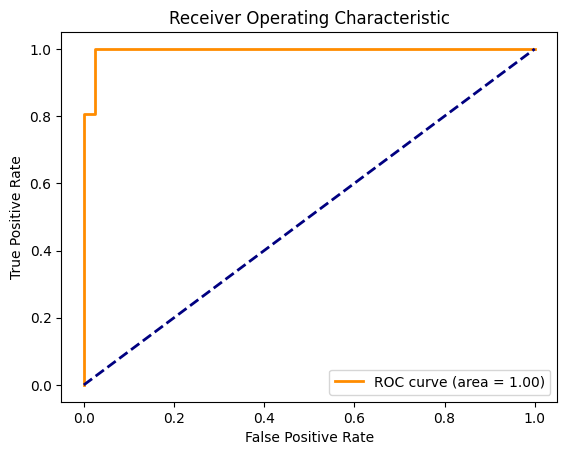

0.9824561403508771


In [9]:
def train_and_evaluate():
  """
  요구사항:
  - train_test_split으로 8:2 분할 (random_state=42, stratify=y).
  - StandardScaler: train에만 fit, train/test 모두 같은 scaler로 transform.
    (⚠️ test에 다시 fit하면 안 되는 이유를 스스로 설명할 수 있어야 함)
  - LogisticRegression(max_iter=1000)으로 학습.
  - classification_report 출력.
  - 혼동행렬을 그려 'week03/confusion_matrix.png'로 저장.
  - predict_proba의 양성 클래스 확률로 ROC 곡선을 그리고 AUC를 제목/범례에 표시,
    대각선(무작위 추측) 기준선도 함께 그려 'week03/roc_curve.png'로 저장.
  """
  data = load_breast_cancer()
  X, y = data.data, data.target

  X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42, stratify=y)

  scaler = StandardScaler()
  scaler.fit(X_train)
  X_train = scaler.transform(X_train)
  X_test = scaler.transform(X_test)
  logistic_regression = LogisticRegression(max_iter=1000)
  logistic_regression.fit(X_train, y_train)
  y_pred = logistic_regression.predict(X_test)
  print(classification_report(y_test, y_pred))
  print(confusion_matrix(y_test, y_pred))
  y_pred_proba = logistic_regression.predict_proba(X_test)
  fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:,1])
  roc_auc = auc(fpr, tpr)
  plt.figure()
  plt.plot(fpr,tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("Receiver Operating Characteristic")
  plt.legend()
  plt.show()
  print(logistic_regression.score(X_test, y_test))


train_and_evaluate()